In [3]:
from pathlib import Path

BASE_DIR = Path("e7_artifacts")
LOG_DIR = BASE_DIR / "logs"
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"
REPORT_DIR = BASE_DIR / "reports"
BERT_DIR = BASE_DIR / "bert"

for folder in [BASE_DIR, LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR, BERT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Созданы папки:")
for folder in [LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR, BERT_DIR]:
    print(folder.resolve())

Созданы папки:
/content/e7_artifacts/logs
/content/e7_artifacts/tables
/content/e7_artifacts/figures
/content/e7_artifacts/reports
/content/e7_artifacts/bert


In [4]:
import pandas as pd

PRESELECTED_PATH = "rusentiment_preselected_posts.csv"
RANDOM_PATH = "rusentiment_random_posts.csv"
TEST_PATH = "rusentiment_test.csv"

pre_df_raw = pd.read_csv(PRESELECTED_PATH)
rand_df_raw = pd.read_csv(RANDOM_PATH)
test_df_raw = pd.read_csv(TEST_PATH)

print("pre_df_raw:", pre_df_raw.shape)
print("rand_df_raw:", rand_df_raw.shape)
print("test_df_raw:", test_df_raw.shape)

pre_df_raw: (6950, 2)
rand_df_raw: (21268, 2)
test_df_raw: (2967, 2)


In [5]:
print("PRESELECTED columns:", pre_df_raw.columns.tolist())
print("RANDOM columns:", rand_df_raw.columns.tolist())
print("TEST columns:", test_df_raw.columns.tolist())

PRESELECTED columns: ['label', 'text']
RANDOM columns: ['label', 'text']
TEST columns: ['label', 'text']


In [6]:
pre_df_raw = pre_df_raw.rename(columns={
    "text": "text",
    "label": "label"
})

rand_df_raw = rand_df_raw.rename(columns={
    "text": "text",
    "label": "label"
})

test_df_raw = test_df_raw.rename(columns={
    "text": "text",
    "label": "label"
})

In [7]:
display(pre_df_raw[["text", "label"]].head())
display(rand_df_raw[["text", "label"]].head())
display(test_df_raw[["text", "label"]].head())

,text,label
0,Прорвём информационную блокаду изнутри.,neutral
1,"Никогда у меня не будет ""одного приложения для...",negative
2,"Кури-и тебя не укусит злая собака, потому что ...",skip
3,"Есть 3 типа людей:\nУмные, которые делают все ...",neutral
4,мегафон чет накрыло,neutral


,text,label
0,"А попа подозревала давно,что ты с кавказа..пер...",negative
1,З прошедшим Днем Ангела)))))))),speech
2,Два дня до отлёта с острова!!!!!!!,skip
3,"Блин, почему эта жизнь столь не справедлива ((((",negative
4,где еще встречать свой день рождения как не на...,skip


,text,label
0,"Александр, тебе к лицу эта пушка :)\n",neutral
1,"Скоро ты вернешься домой, грязный, не бритый н...",positive
2,помниш...)),neutral
3,Мы просто с [id12210212|Елисеем] психанули )...,skip
4,"ой, прости забыла поздравить, с праздничьком, ...",speech


In [8]:
train_df_raw = pd.concat([pre_df_raw, rand_df_raw], ignore_index=True)

print("train_df_raw:", train_df_raw.shape)
print("test_df_raw:", test_df_raw.shape)

train_df_raw: (28218, 2)
test_df_raw: (2967, 2)


In [9]:
print("Train raw classes:")
print(sorted(train_df_raw["label"].astype(str).unique()))

print("\nTest raw classes:")
print(sorted(test_df_raw["label"].astype(str).unique()))

print("\nTrain raw class counts:")
print(train_df_raw["label"].value_counts())

print("\nTest raw class counts:")
print(test_df_raw["label"].value_counts())

Train raw classes:
['negative', 'neutral', 'positive', 'skip', 'speech']

Test raw classes:
['negative', 'neutral', 'positive', 'skip', 'speech']

Train raw class counts:
label
neutral     11300
positive     6110
skip         4094
negative     3654
speech       3060
Name: count, dtype: int64

Test raw class counts:
label
neutral     1420
positive     536
speech       407
skip         346
negative     258
Name: count, dtype: int64


In [10]:
TARGET_CLASSES = ["negative", "neutral", "positive"]

train_df = train_df_raw[train_df_raw["label"].isin(TARGET_CLASSES)].copy()
test_df = test_df_raw[test_df_raw["label"].isin(TARGET_CLASSES)].copy()

print("train_df filtered:", train_df.shape)
print("test_df filtered:", test_df.shape)

train_df filtered: (21064, 2)
test_df filtered: (2214, 2)


In [11]:
raw_train_classes = sorted(train_df_raw["label"].astype(str).unique())
raw_test_classes = sorted(test_df_raw["label"].astype(str).unique())

filtered_train_classes = sorted(train_df["label"].astype(str).unique())
filtered_test_classes = sorted(test_df["label"].astype(str).unique())

removed_train_classes = sorted(set(raw_train_classes) - set(filtered_train_classes))
removed_test_classes = sorted(set(raw_test_classes) - set(filtered_test_classes))

print("Removed train classes:", removed_train_classes)
print("Removed test classes:", removed_test_classes)

Removed train classes: ['skip', 'speech']
Removed test classes: ['skip', 'speech']


In [12]:
print("Missing values in train:")
print(train_df[["text", "label"]].isna().sum())

print("\nMissing values in test:")
print(test_df[["text", "label"]].isna().sum())

Missing values in train:
text     0
label    0
dtype: int64

Missing values in test:
text     0
label    0
dtype: int64


In [13]:
train_df = train_df.dropna(subset=["text", "label"]).copy()
test_df = test_df.dropna(subset=["text", "label"]).copy()

print("After dropna train:", train_df.shape)
print("After dropna test:", test_df.shape)

After dropna train: (21064, 2)
After dropna test: (2214, 2)


In [14]:
train_duplicates = train_df.duplicated(subset=["text", "label"]).sum()
test_duplicates = test_df.duplicated(subset=["text", "label"]).sum()

print("Train duplicates:", train_duplicates)
print("Test duplicates:", test_duplicates)

Train duplicates: 41
Test duplicates: 0


In [15]:
train_df = train_df.drop_duplicates(subset=["text", "label"]).copy()
test_df = test_df.drop_duplicates(subset=["text", "label"]).copy()

print("After dedup train:", train_df.shape)
print("After dedup test:", test_df.shape)

After dedup train: (21023, 2)
After dedup test: (2214, 2)


In [16]:
from sklearn.model_selection import train_test_split

SEED = 42

train_final_df, val_final_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=SEED,
    stratify=train_df["label"]
)

print("train_final_df:", train_final_df.shape)
print("val_final_df:", val_final_df.shape)
print("test_df:", test_df.shape)

train_final_df: (18920, 2)
val_final_df: (2103, 2)
test_df: (2214, 2)


In [17]:
train_df.to_csv(TABLE_DIR / "rusentiment_train_filtered.csv", index=False, encoding="utf-8-sig")
test_df.to_csv(TABLE_DIR / "rusentiment_test_filtered.csv", index=False, encoding="utf-8-sig")

train_final_df.to_csv(TABLE_DIR / "rusentiment_train_final.csv", index=False, encoding="utf-8-sig")
val_final_df.to_csv(TABLE_DIR / "rusentiment_val_final.csv", index=False, encoding="utf-8-sig")
test_df.to_csv(TABLE_DIR / "rusentiment_test_final.csv", index=False, encoding="utf-8-sig")

print("Processed E7 splits saved.")

Processed E7 splits saved.


In [18]:
dataset_info = f"""
E7 SECOND DATASET DESCRIPTION

Dataset: RuSentiment

Train raw shape: {train_df_raw.shape}
Test raw shape: {test_df_raw.shape}

Target classes:
{TARGET_CLASSES}

Removed classes from train:
{removed_train_classes}

Removed classes from test:
{removed_test_classes}

Filtered train shape:
{train_df.shape}

Filtered test shape:
{test_df.shape}

Train final shape:
{train_final_df.shape}

Validation final shape:
{val_final_df.shape}

Test final shape:
{test_df.shape}

Train class distribution:
{train_df['label'].value_counts().to_string()}

Validation class distribution:
{val_final_df['label'].value_counts().to_string()}

Test class distribution:
{test_df['label'].value_counts().to_string()}
"""

with open(LOG_DIR / "e7_dataset_info.txt", "w", encoding="utf-8") as f:
    f.write(dataset_info)

print("Saved:", LOG_DIR / "e7_dataset_info.txt")

Saved: e7_artifacts/logs/e7_dataset_info.txt


In [19]:
X_train = train_final_df["text"].copy()
y_train = train_final_df["label"].copy()

X_val = val_final_df["text"].copy()
y_val = val_final_df["label"].copy()

X_test = test_df["text"].copy()
y_test = test_df["label"].copy()

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

char_vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95
)

X_train_char = char_vectorizer.fit_transform(X_train)
X_val_char = char_vectorizer.transform(X_val)
X_test_char = char_vectorizer.transform(X_test)

print("X_train_char:", X_train_char.shape)
print("X_val_char:", X_val_char.shape)
print("X_test_char:", X_test_char.shape)

X_train_char: (18920, 127910)
X_val_char: (2103, 127910)
X_test_char: (2214, 127910)


In [21]:
import time
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

sgd_model = SGDClassifier(
    loss="hinge",
    max_iter=1000,
    tol=1e-3,
    random_state=SEED
)

start_time = time.time()
sgd_model.fit(X_train_char, y_train)
train_time_classical = time.time() - start_time

y_pred_classical = sgd_model.predict(X_test_char)

acc_classical = accuracy_score(y_test, y_pred_classical)
precision_w_classical, recall_w_classical, f1_w_classical, _ = precision_recall_fscore_support(
    y_test, y_pred_classical, average="weighted", zero_division=0
)
f1_macro_classical = f1_score(y_test, y_pred_classical, average="macro")

report_classical = classification_report(y_test, y_pred_classical, digits=4, zero_division=0)
print(report_classical)

              precision    recall  f1-score   support

    negative     0.7414    0.3333    0.4599       258
     neutral     0.7997    0.9000    0.8469      1420
    positive     0.7240    0.6754    0.6988       536

    accuracy                         0.7796      2214
   macro avg     0.7550    0.6362    0.6686      2214
weighted avg     0.7746    0.7796    0.7660      2214



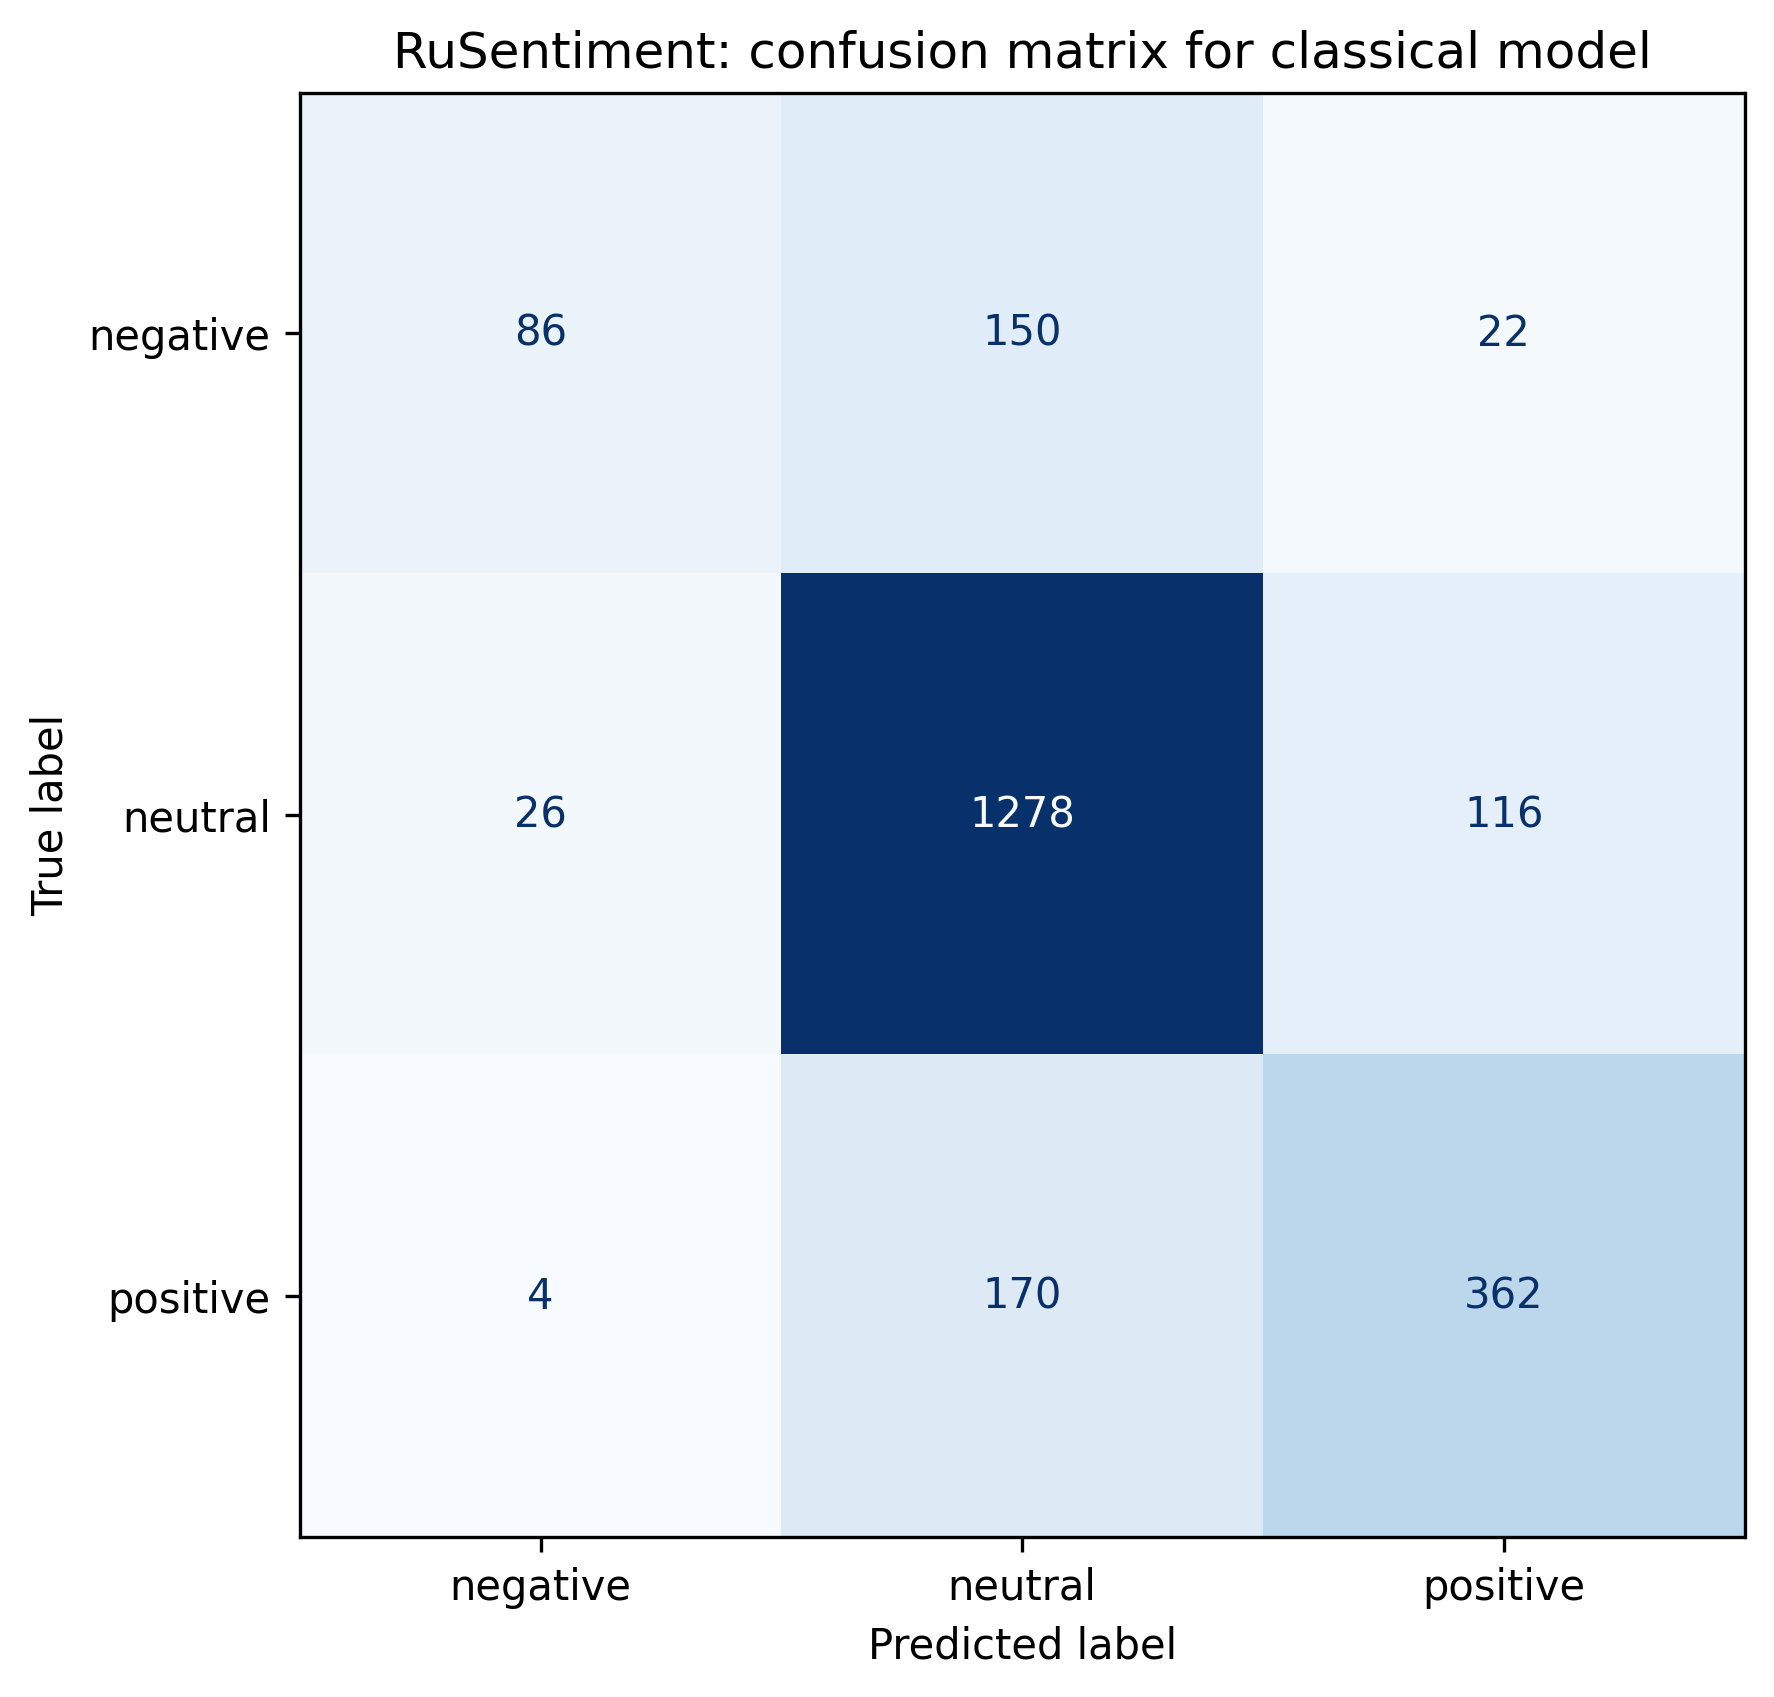

In [22]:
with open(REPORT_DIR / "classification_report_rusentiment_classical.txt", "w", encoding="utf-8") as f:
    f.write(report_classical)

labels_order = ["negative", "neutral", "positive"]

cm_classical = confusion_matrix(y_test, y_pred_classical, labels=labels_order)
disp_classical = ConfusionMatrixDisplay(confusion_matrix=cm_classical, display_labels=labels_order)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp_classical.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("RuSentiment: confusion matrix for classical model")
plt.tight_layout()
plt.savefig(FIG_DIR / "rusentiment_classical_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [24]:
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [25]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}
id2label = {v: k for k, v in label2id.items()}

train_hf = train_final_df.copy()
val_hf = val_final_df.copy()
test_hf = test_df.copy()

train_hf["label_id"] = train_hf["label"].map(label2id)
val_hf["label_id"] = val_hf["label"].map(label2id)
test_hf["label_id"] = test_hf["label"].map(label2id)

In [26]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_hf[["text", "label_id"]])
val_dataset = Dataset.from_pandas(val_hf[["text", "label_id"]])
test_dataset = Dataset.from_pandas(test_hf[["text", "label_id"]])

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label_id', '__index_level_0__'],
    num_rows: 18920
})
Dataset({
    features: ['text', 'label_id', '__index_level_0__'],
    num_rows: 2103
})
Dataset({
    features: ['text', 'label_id', '__index_level_0__'],
    num_rows: 2214
})


In [27]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "cointegrated/rubert-tiny2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

train_tokenized = train_tokenized.rename_column("label_id", "labels")
val_tokenized = val_tokenized.rename_column("label_id", "labels")
test_tokenized = test_tokenized.rename_column("label_id", "labels")

train_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/2103 [00:00<?, ? examples/s]

Map:   0%|          | 0/2214 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

In [28]:
import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    precision_w = precision_metric.compute(predictions=preds, references=labels, average="weighted")["precision"]
    recall_w = recall_metric.compute(predictions=preds, references=labels, average="weighted")["recall"]
    f1_w = f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]
    f1_m = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]

    return {
        "accuracy": accuracy,
        "precision_weighted": precision_w,
        "recall_weighted": recall_w,
        "f1_weighted": f1_w,
        "f1_macro": f1_m
    }

In [29]:
from transformers import TrainingArguments, Trainer

device = "cuda" if torch.cuda.is_available() else "cpu"

training_args = TrainingArguments(
    output_dir="./rusentiment_rubert_tiny_tuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    num_train_epochs=3,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none",
    fp16=True if device == "cuda" else False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics
)

In [30]:
start_time_bert = time.time()
trainer.train()
train_time_bert = time.time() - start_time_bert

print("RuSentiment BERT train time:", round(train_time_bert, 4))

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
1,0.655197,0.643592,0.704708,0.709997,0.704708,0.706287,0.669802
2,0.534915,0.621185,0.728008,0.726228,0.728008,0.726411,0.685251
3,0.458029,0.627163,0.734189,0.732440,0.734189,0.733164,0.694610


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

RuSentiment BERT train time: 152.5717


In [31]:
pred_output = trainer.predict(test_tokenized)

y_pred_bert_ids = np.argmax(pred_output.predictions, axis=-1)
y_true_bert_ids = pred_output.label_ids

label_names = ["negative", "neutral", "positive"]
y_pred_bert = np.array([label_names[i] for i in y_pred_bert_ids])
y_true_bert = np.array([label_names[i] for i in y_true_bert_ids])

In [32]:
acc_bert = accuracy_score(y_true_bert, y_pred_bert)
precision_w_bert, recall_w_bert, f1_w_bert, _ = precision_recall_fscore_support(
    y_true_bert, y_pred_bert, average="weighted", zero_division=0
)
f1_macro_bert = f1_score(y_true_bert, y_pred_bert, average="macro")

report_bert = classification_report(y_true_bert, y_pred_bert, digits=4, zero_division=0)
print(report_bert)

with open(REPORT_DIR / "classification_report_rusentiment_bert_tuned.txt", "w", encoding="utf-8") as f:
    f.write(report_bert)

              precision    recall  f1-score   support

    negative     0.5616    0.6357    0.5964       258
     neutral     0.8544    0.8014    0.8270      1420
    positive     0.6695    0.7369    0.7016       536

    accuracy                         0.7665      2214
   macro avg     0.6952    0.7247    0.7083      2214
weighted avg     0.7755    0.7665    0.7698      2214



In [33]:
acc_bert = accuracy_score(y_true_bert, y_pred_bert)
precision_w_bert, recall_w_bert, f1_w_bert, _ = precision_recall_fscore_support(
    y_true_bert, y_pred_bert, average="weighted", zero_division=0
)
f1_macro_bert = f1_score(y_true_bert, y_pred_bert, average="macro")

report_bert = classification_report(y_true_bert, y_pred_bert, digits=4, zero_division=0)
print(report_bert)

with open(REPORT_DIR / "classification_report_rusentiment_bert_tuned.txt", "w", encoding="utf-8") as f:
    f.write(report_bert)

              precision    recall  f1-score   support

    negative     0.5616    0.6357    0.5964       258
     neutral     0.8544    0.8014    0.8270      1420
    positive     0.6695    0.7369    0.7016       536

    accuracy                         0.7665      2214
   macro avg     0.6952    0.7247    0.7083      2214
weighted avg     0.7755    0.7665    0.7698      2214



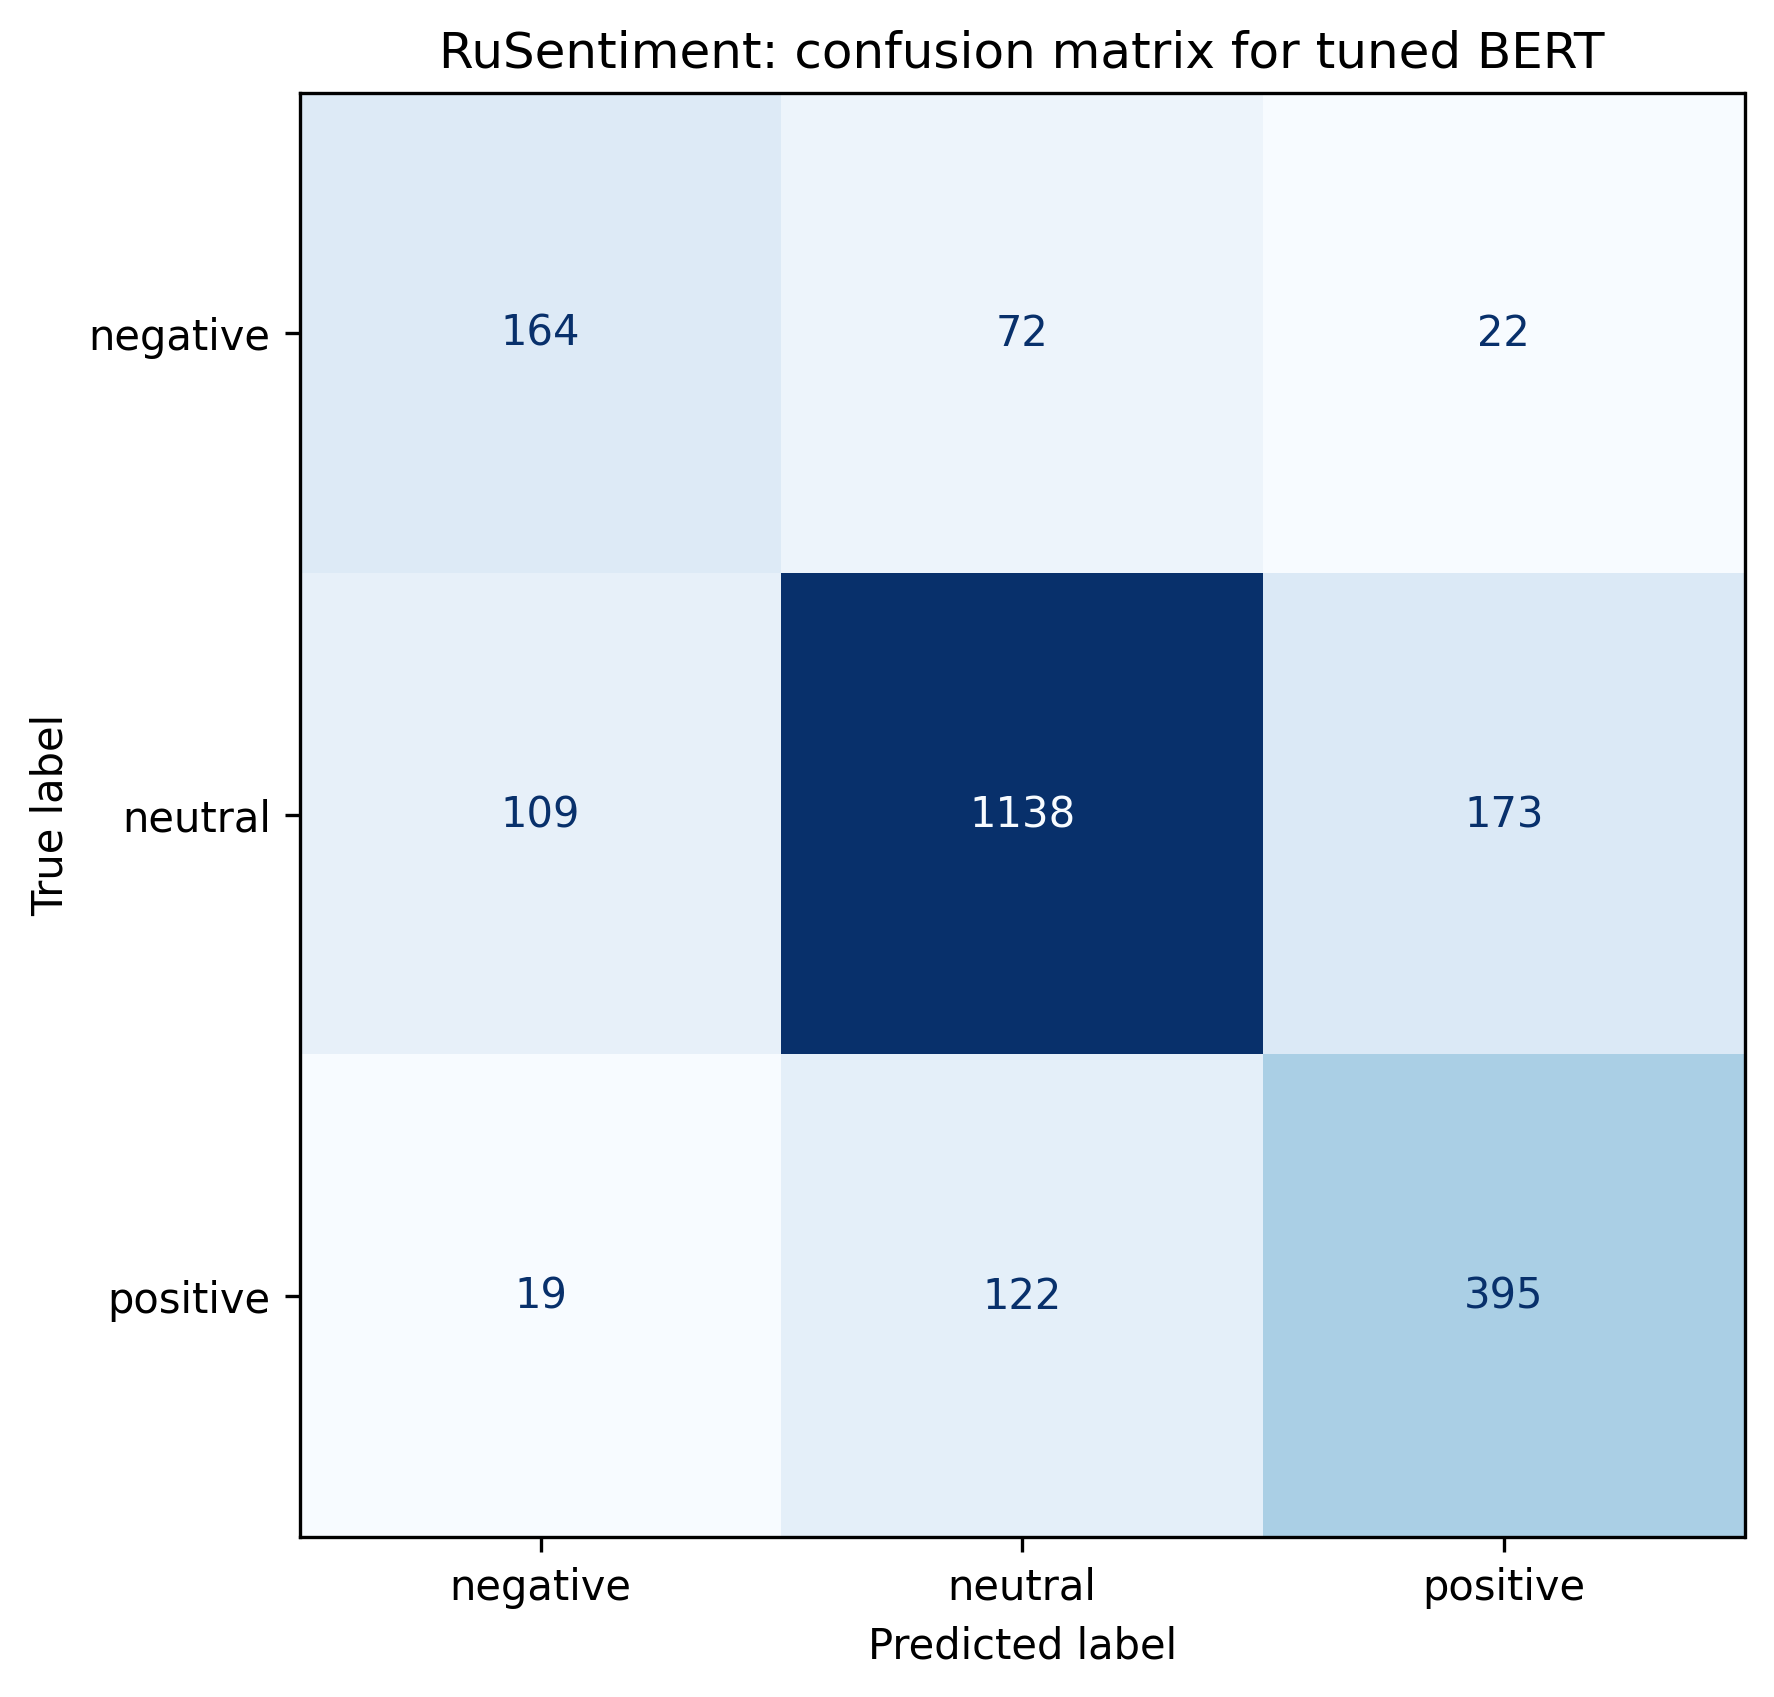

In [34]:
cm_bert = confusion_matrix(y_true_bert, y_pred_bert, labels=labels_order)
disp_bert = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp_bert.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("RuSentiment: confusion matrix for tuned BERT")
plt.tight_layout()
plt.savefig(FIG_DIR / "rusentiment_bert_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
save_path = BERT_DIR / "rusentiment_rubert_tiny_tuned_model"
save_path.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(save_path))
tokenizer.save_pretrained(str(save_path))

print("Model saved to:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: e7_artifacts/bert/rusentiment_rubert_tiny_tuned_model


In [36]:
e7_results = []

e7_results.append({
    "model": "SGDClassifier hinge + char TF-IDF",
    "representation": "char TF-IDF (3,5)",
    "dataset": "RuSentiment",
    "accuracy": round(acc_classical, 4),
    "precision_weighted": round(precision_w_classical, 4),
    "recall_weighted": round(recall_w_classical, 4),
    "weighted_f1": round(f1_w_classical, 4),
    "macro_f1": round(f1_macro_classical, 4),
    "train_time_sec": round(train_time_classical, 4),
    "seed": SEED
})

e7_results.append({
    "model": "ruBERT-tiny2 tuned on RuSentiment",
    "representation": "Tokenizer",
    "dataset": "RuSentiment",
    "accuracy": round(acc_bert, 4),
    "precision_weighted": round(precision_w_bert, 4),
    "recall_weighted": round(recall_w_bert, 4),
    "weighted_f1": round(f1_w_bert, 4),
    "macro_f1": round(f1_macro_bert, 4),
    "train_time_sec": round(train_time_bert, 4),
    "seed": SEED
})

e7_results_df = pd.DataFrame(e7_results)
e7_results_df = e7_results_df.sort_values(by="weighted_f1", ascending=False).reset_index(drop=True)

display(e7_results_df)

,model,representation,dataset,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,train_time_sec,seed
0,ruBERT-tiny2 tuned on RuSentiment,Tokenizer,RuSentiment,0.7665,0.7755,0.7665,0.7698,0.7083,152.5717,42
1,SGDClassifier hinge + char TF-IDF,"char TF-IDF (3,5)",RuSentiment,0.7796,0.7746,0.7796,0.7660,0.6686,0.5965,42


In [37]:
e7_results_df.to_csv(TABLE_DIR / "e7_second_dataset_results.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e7_second_dataset_results.csv")

Saved: e7_artifacts/tables/e7_second_dataset_results.csv


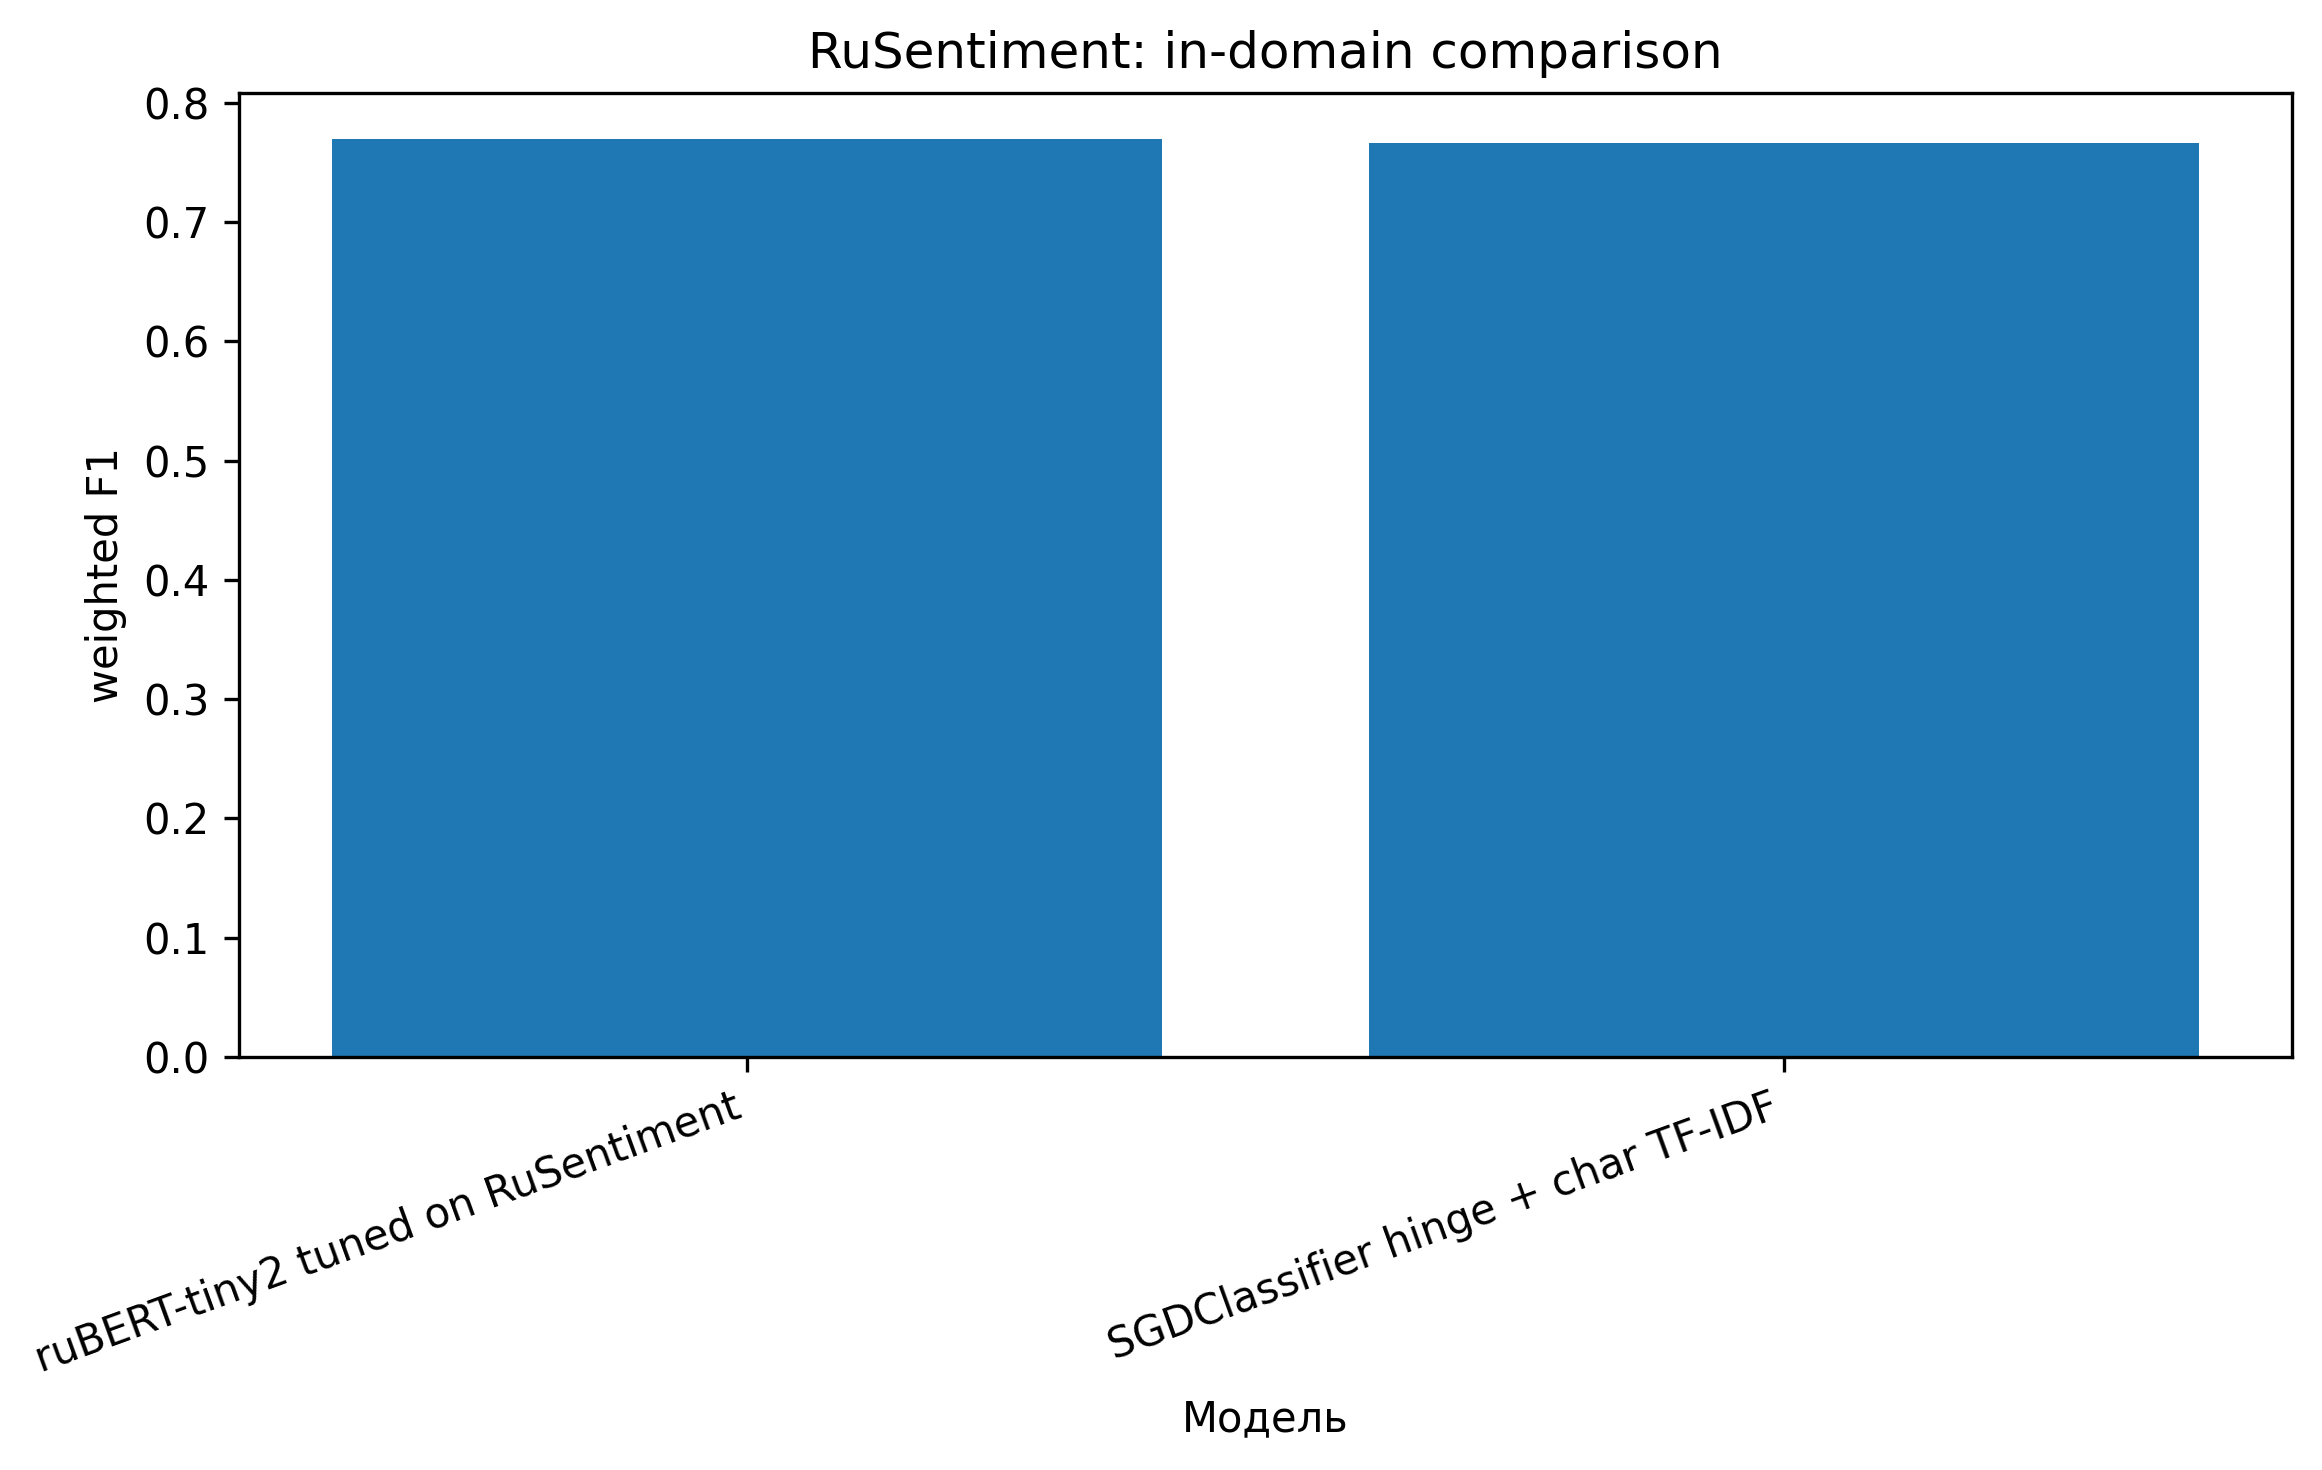

In [38]:
plot_df = e7_results_df.sort_values(by="weighted_f1", ascending=False)

plt.figure(figsize=(8, 5), dpi=300)
plt.bar(plot_df["model"], plot_df["weighted_f1"])
plt.title("RuSentiment: in-domain comparison")
plt.xlabel("Модель")
plt.ylabel("weighted F1")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "e7_second_dataset_weighted_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
experiment_ids = [f"E7-{i+1}" for i in range(len(e7_results_df))]

e7_registry = e7_results_df.copy()
e7_registry.insert(0, "experiment_id", experiment_ids)
e7_registry["train_split"] = "rusentiment_train_final"
e7_registry["val_split"] = "rusentiment_val_final"
e7_registry["test_split"] = "rusentiment_test_final"
e7_registry["status"] = "completed"

display(e7_registry)

,experiment_id,model,representation,dataset,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,train_time_sec,seed,train_split,val_split,test_split,status
0,E7-1,ruBERT-tiny2 tuned on RuSentiment,Tokenizer,RuSentiment,0.7665,0.7755,0.7665,0.7698,0.7083,152.5717,42,rusentiment_train_final,rusentiment_val_final,rusentiment_test_final,completed
1,E7-2,SGDClassifier hinge + char TF-IDF,"char TF-IDF (3,5)",RuSentiment,0.7796,0.7746,0.7796,0.7660,0.6686,0.5965,42,rusentiment_train_final,rusentiment_val_final,rusentiment_test_final,completed


In [40]:
e7_registry.to_csv(TABLE_DIR / "e7_experiment_registry.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e7_experiment_registry.csv")

Saved: e7_artifacts/tables/e7_experiment_registry.csv


In [41]:
e7_summary = f"""
E7 SECOND DATASET IN-DOMAIN SUMMARY

Second dataset:
RuSentiment

Target classes:
negative / neutral / positive

Removed classes:
{removed_train_classes} (train), {removed_test_classes} (test)

Train final shape:
{train_final_df.shape}

Validation final shape:
{val_final_df.shape}

Test final shape:
{test_df.shape}

Results:
{e7_results_df[["model", "accuracy", "weighted_f1", "macro_f1"]].to_string(index=False)}
"""

with open(LOG_DIR / "e7_summary.txt", "w", encoding="utf-8") as f:
    f.write(e7_summary)

print("Saved:", LOG_DIR / "e7_summary.txt")

Saved: e7_artifacts/logs/e7_summary.txt
